In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import List, Tuple

In [ ]:

def generate_cities(n_cities: int, size: int = 300, seed: int = None) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)  # Ustawienie seeda dla losowości NumPy
    return np.random.randint(0, size, size=(n_cities, 2))


def plot_cities(cities: np.ndarray):
    plt.figure(figsize=(8, 8))
    plt.scatter(cities[:, 0], cities[:, 1], c='red', s=50, zorder=5)
    for i, (x, y) in enumerate(cities):
        plt.text(x + 2, y + 2, str(i), fontsize=9)
    plt.title("Wylosowane miasta na płaszczyźnie")
    plt.grid(True)
    plt.xlim(0, 310)
    plt.ylim(0, 310)
    plt.show()

# Wizualizacja miast w celu zaczęcia projektu

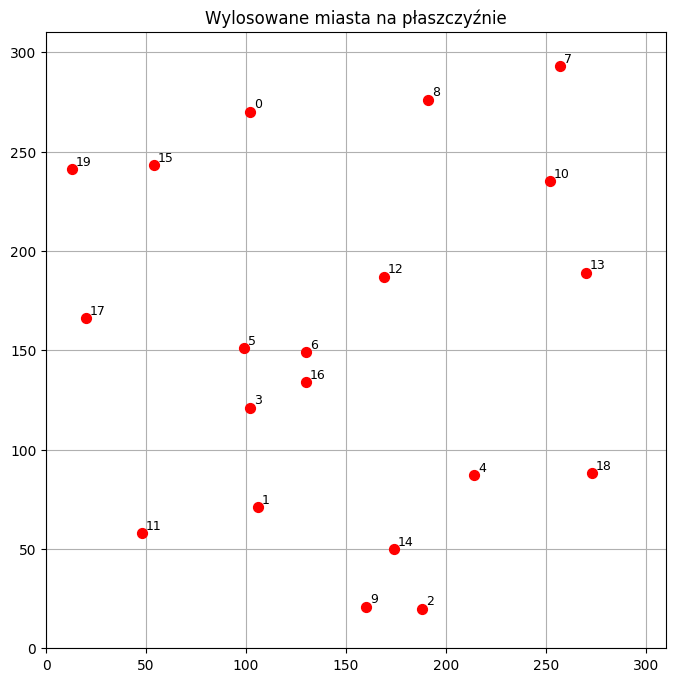

In [ ]:
cities = generate_cities(20, seed=42)  # np. 20 miast
plot_cities(cities)

In [ ]:
cities

array([[249.86837915, 236.78939366],
       [285.46376803,  66.40452433],
       [ 33.50647128, 177.45351153],
       [190.56897506, 271.09171584],
       [213.44635589, 239.49042142],
       [148.76680702, 167.45200366],
       [ 10.44829823,  42.06365315],
       [228.55947146, 100.66118548],
       [113.55208323, 169.95725542],
       [ 32.09515556,   6.16047318],
       [ 78.90323471, 234.71813298],
       [ 29.44354072, 263.53034489],
       [182.78104266, 261.91441741],
       [ 18.74529826, 249.30730958],
       [203.40605719, 143.87488217],
       [ 34.71784206,  35.19046553],
       [ 69.9429669 , 187.39684728],
       [155.20570183,  39.2684494 ],
       [155.60955346,  32.46442312],
       [152.71052652,  80.89583981]])

In [ ]:
def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    return np.linalg.norm(a - b)

def total_distance(path: List[int], cities: np.ndarray) -> float:
    dist = sum(
        euclidean_distance(cities[path[i]], cities[path[i + 1]])
        for i in range(len(path) - 1)
    )
    dist += euclidean_distance(cities[path[-1]], cities[path[0]])
    return dist


In [ ]:
def init_population(n: int, n_cities: int) -> List[List[int]]:
    base = list(range(n_cities))
    return [random.sample(base, len(base)) for _ in range(n)]


In [ ]:
def roulette_selection(population: List[List[int]], fitness: List[float]) -> List[int]:
    inv_fitness = 1 / np.array(fitness)   # chcemy aby krotsze trasy mialy wieksza szanse
    probs = inv_fitness / inv_fitness.sum() # liczymy prawd gdzie krotsze trasy maja wieksza sznase wylosowania
    return population[np.random.choice(len(population), p=probs)]  # losuje index ale zgodnie z tym prawd.




In [ ]:
[x for _, x in sorted(zip([3, 6, 5, 2], [[1, 2, 3],
                                         [3, 4, 5],
                                         [5, 5, 5],
                                         [5, 5, 5]]))]

[[5, 5, 5], [1, 2, 3], [5, 5, 5], [3, 4, 5]]

In [ ]:
def rank_selection(population: List[List[int]], fitness: List[float]) -> List[int]:
    sorted_pop = [x for _, x in sorted(zip(fitness, population))]
    ranks = np.arange(1, len(population)+1)
    probs = ranks / ranks.sum()
    return sorted_pop[np.random.choice(len(population), p=probs)]


In [ ]:
sorted(random.sample(range(10), 2))
child = [None]*10
child
parent1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
child[2:9+1] = parent1[2:9]
child

[None, None, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
def crossover(parent1: List[int], parent2: List[int]) -> List[int]:
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None]*size
    child[start:end+1] = parent1[start:end+1]
    p2_idx = 0
    for i in range(size):
        if child[i] is None:
            while parent2[p2_idx] in child:
                p2_idx += 1
            child[i] = parent2[p2_idx]
    return child


In [ ]:
random.random()

0.8758541740583106

In [ ]:
def mutate(individual: List[int], mutation_rate: float):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]

In [ ]:
parent1 = [9, 5, 3, 8, 4, 7, 10, 2, 1, 6]
parent2 = [1, 2, 4, 3, 6, 5, 7, 8, 9, 10]
[4, 3, 5, 7, 8, 9, 10, 2, 1, 6]
crossover(parent1, parent2)

0, 5


[9, 5, 3, 8, 4, 7, 1, 2, 6, 10]

In [ ]:


def genetic_algorithm(
    cities: np.ndarray,
    pop_size=100,
    crossover_rate=1.0,
    mutation_rate=0.05,
    n_generations=500,
    selection_method="roulette"
):
    n_cities = len(cities)
    population = init_population(pop_size, n_cities)
    best_history = []
    avg_history = []
    worst_history = []


    global_best = float('inf')
    global_best_path = None
    paths_per_gen = []
    for generation in range(n_generations):
        fitness = [total_distance(p, cities) for p in population]
        new_population = []


        best_in_gen = min(fitness)
        best_path_in_gen = population[np.argmin(fitness)]
        if best_in_gen < global_best:
            global_best = best_in_gen  # wartosc odleglosci sumarycznej
            global_best_path = best_path_in_gen[:]  # osobnik



        for _ in range(pop_size):   # poniewaz nowa populacja ma liczyc tyle samo ile stara populacja
            if selection_method == "roulette":
                parent1 = roulette_selection(population, fitness) # lista list czyli populacja osobnikow , fitness czyli tablica dl 100 bo 100 odl dla 100 osobnikow
                parent2 = roulette_selection(population, fitness)
            else:
                parent1 = rank_selection(population, fitness)
                parent2 = rank_selection(population, fitness)

            if random.random() < crossover_rate:
                child = crossover(parent1, parent2)
            else:
                child = parent1[:]

            mutate(child, mutation_rate)
            new_population.append(child)

        population = new_population

        # Logging
        fitness = [total_distance(p, cities) for p in population]
        best_history.append(min(fitness))
        avg_history.append(np.mean(fitness))
        worst_history.append(max(fitness))

        if generation % 10 == 0:
            paths_per_gen.append((generation, best_path_in_gen[:], best_in_gen))
            print(f"Pokolenie {generation}: Najlepszy = {min(fitness):.2f}")

    # Zwraca najlepsze znalezione rozwiązanie i historię
    best_idx = np.argmin(fitness)
    return global_best_path, population[best_idx], best_history, avg_history, worst_history, paths_per_gen   # najlepszy osobnik we wszystkich gemeracjach, tylko w ostaniej generacji najlepszy


In [ ]:
def plot_solution(cities: np.ndarray, path: List[int], gen: int = None):
    plt.figure(figsize=(8, 8))
    path_loop = path + [path[0]]
    plt.plot(cities[path_loop, 0], cities[path_loop, 1], 'b-', linewidth=2, label="Najlepsza trasa")
    plt.scatter(cities[:, 0], cities[:, 1], color='red')
    for i, (x, y) in enumerate(cities):
        plt.text(x + 2, y + 2, str(i), fontsize=9)
    if gen is not None:
        plt.title(f"Najlepsza trasa w pokoleniu {gen}")
    plt.grid()
    plt.legend()
    plt.show()


In [ ]:
# jak sie zmienia wykres najlepszych i najgorszych sumarycznych odleglosci miedzy wszystkimi miastami + dodatek wykres sredniej
def plot_history(best, avg, worst):
    plt.figure(figsize=(10, 4))
    plt.plot(best, label="Najlepszy", linewidth=2)
    plt.plot(avg, label="Średni", linestyle='--')
    plt.plot(worst, label="Najgorszy", linestyle=':')
    plt.title("Ewolucja funkcji celu")
    plt.xlabel("Pokolenie")
    plt.ylabel("Długość trasy")
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:
def generate_cities_on_circle(n_cities: int, radius=120, center=(150, 150), seed=None) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)
    angles = np.linspace(0, 2 * np.pi, n_cities, endpoint=False)
    x = center[0] + radius * np.cos(angles)
    y = center[1] + radius * np.sin(angles)
    return np.column_stack((x, y))


In [ ]:
from matplotlib.animation import FuncAnimation
def animate_evolution(cities: np.ndarray, paths_per_gen: List[Tuple[int, List[int], float]], save_as_gif=False):
    fig, ax = plt.subplots(figsize=(8, 8))
    scat = ax.scatter(cities[:, 0], cities[:, 1], color='red')
    line, = ax.plot([], [], 'b-', linewidth=2)
    title = ax.text(0.5, 1.05, '', transform=ax.transAxes, ha='center', fontsize=12)
    for i, (x, y) in enumerate(cities):
        ax.text(x + 2, y + 2, str(i), fontsize=9)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 300)
    ax.grid()
    def update(frame):
        gen, path, dist = paths_per_gen[frame]
        looped_path = path + [path[0]]
        x = cities[looped_path, 0]
        y = cities[looped_path, 1]
        line.set_data(x, y)
        title.set_text(f"Pokolenie {gen} | Długość trasy: {dist:.2f}")
        return line, title
    anim = FuncAnimation(fig, update, frames=len(paths_per_gen), interval=400, repeat=False)
    if save_as_gif:
        anim.save("evolution.gif", writer='pillow')
        print("Animacja zapisana jako evolution.gif")
    else:
        plt.show()


In [ ]:
cities = generate_cities(20, seed=42)
best_global_path, best_path, best_h, avg_h, worst_h, paths_per_gen = genetic_algorithm(
    cities,
    pop_size=150,
    crossover_rate=0.95,
    mutation_rate=0.05,
    n_generations=200,
    selection_method="rank"
)




Pokolenie 0: Najlepszy = 2665.14
Pokolenie 10: Najlepszy = 2859.15
Pokolenie 20: Najlepszy = 2859.29
Pokolenie 30: Najlepszy = 2832.20
Pokolenie 40: Najlepszy = 2913.84
Pokolenie 50: Najlepszy = 2852.79
Pokolenie 60: Najlepszy = 2670.17
Pokolenie 70: Najlepszy = 2788.46
Pokolenie 80: Najlepszy = 2889.38
Pokolenie 90: Najlepszy = 2894.93
Pokolenie 100: Najlepszy = 2797.27
Pokolenie 110: Najlepszy = 2803.09
Pokolenie 120: Najlepszy = 2879.81
Pokolenie 130: Najlepszy = 2837.42
Pokolenie 140: Najlepszy = 2667.17
Pokolenie 150: Najlepszy = 2929.38
Pokolenie 160: Najlepszy = 2807.09
Pokolenie 170: Najlepszy = 2861.81
Pokolenie 180: Najlepszy = 2837.84
Pokolenie 190: Najlepszy = 2861.53


# Sam końcowy wynik dla najlepszego osobnika biorąc pod uwagę wszystkie generacje

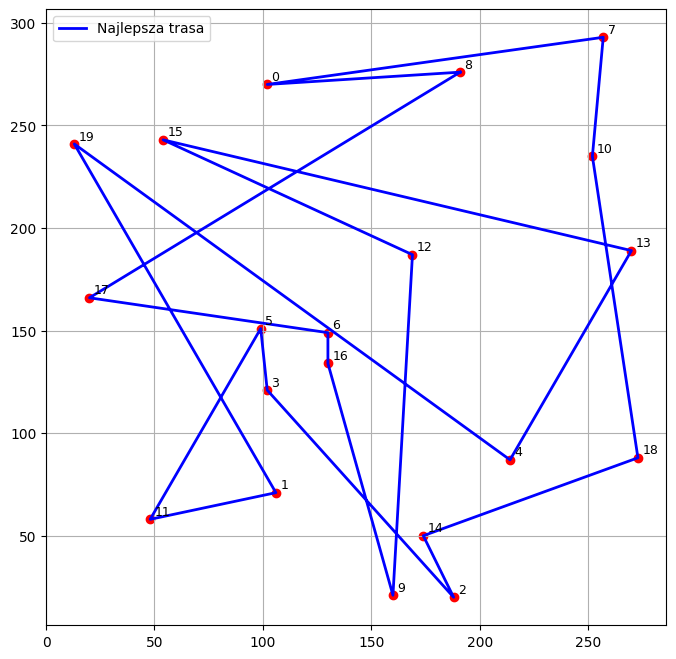

In [ ]:
plot_solution(cities, best_global_path)


# Ewolucja funkcji celu

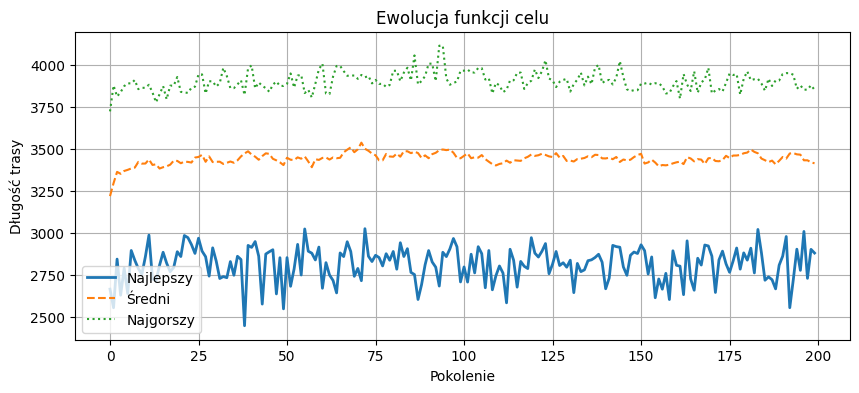

In [ ]:
plot_history(best_h, avg_h, worst_h)

# Animacja do pobrania jako gif - tu będzie wyświetlany tylko końcowy rezultat

Animacja zapisana jako evolution.gif


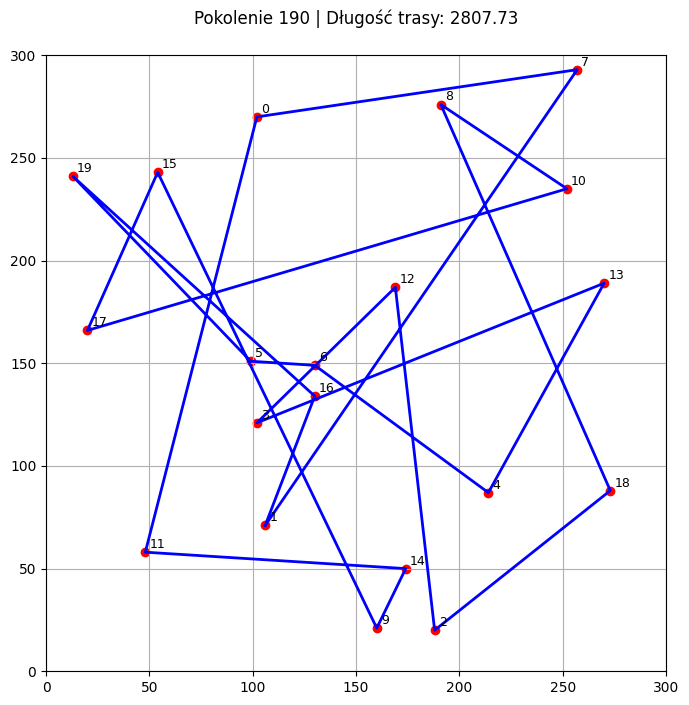

In [ ]:
animate_evolution(cities, paths_per_gen, save_as_gif=True)


In [ ]:
cities = generate_cities_on_circle(20, seed=42)
best_global_path, best_path, best_h, avg_h, worst_h, paths_per_gen = genetic_algorithm(
    cities,
    pop_size=150,
    crossover_rate=0.95,
    mutation_rate=0.05,
    n_generations=200,
    selection_method="roulette"
)




Pokolenie 0: Najlepszy = 2212.48
Pokolenie 10: Najlepszy = 2146.85
Pokolenie 20: Najlepszy = 2297.31
Pokolenie 30: Najlepszy = 2417.10
Pokolenie 40: Najlepszy = 2344.42
Pokolenie 50: Najlepszy = 2263.49
Pokolenie 60: Najlepszy = 1814.64
Pokolenie 70: Najlepszy = 2415.84
Pokolenie 80: Najlepszy = 2181.08
Pokolenie 90: Najlepszy = 2300.46
Pokolenie 100: Najlepszy = 2395.60
Pokolenie 110: Najlepszy = 2475.41
Pokolenie 120: Najlepszy = 2350.73
Pokolenie 130: Najlepszy = 2244.40
Pokolenie 140: Najlepszy = 2478.16
Pokolenie 150: Najlepszy = 2275.07
Pokolenie 160: Najlepszy = 2251.96
Pokolenie 170: Najlepszy = 2148.26
Pokolenie 180: Najlepszy = 2130.06
Pokolenie 190: Najlepszy = 2230.14


# Sprawdzenie na okręgu

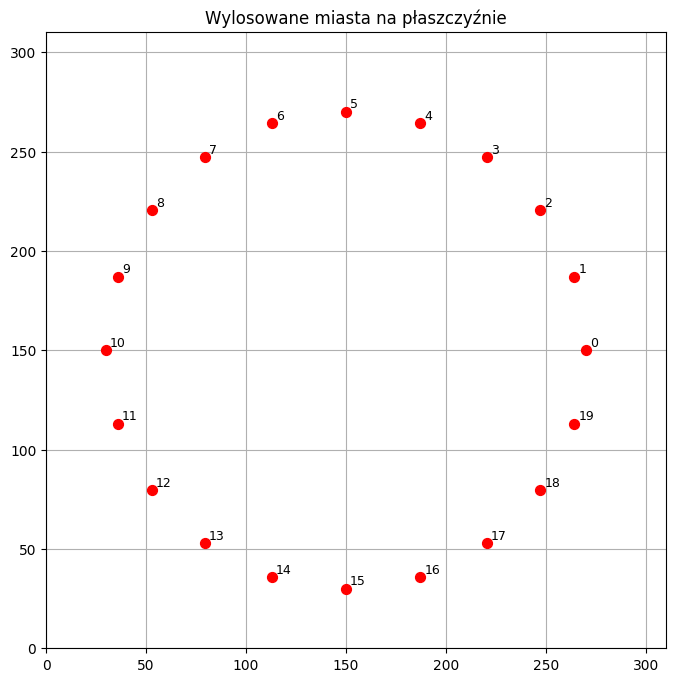

In [ ]:
plot_cities(cities)

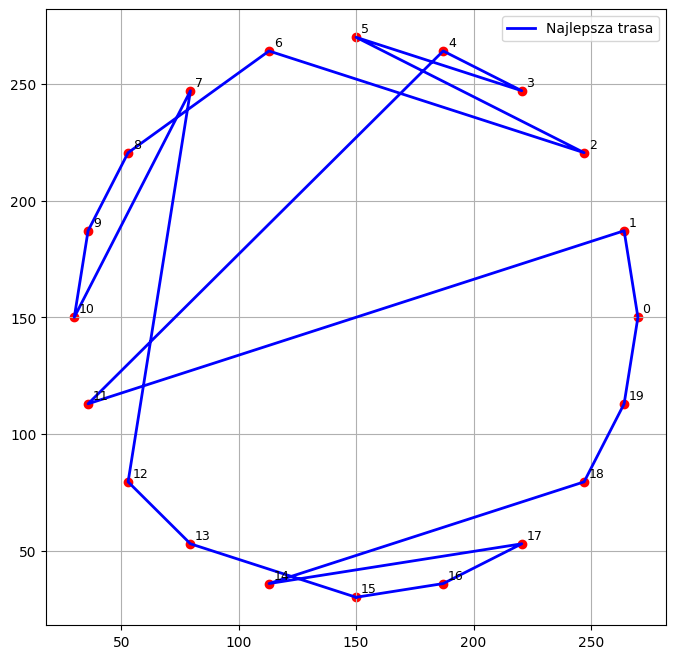

In [ ]:

plot_solution(cities, best_global_path)

In [ ]:
best_global_path

[15, 13, 12, 7, 10, 9, 8, 6, 2, 5, 3, 4, 11, 1, 0, 19, 18, 14, 17, 16]

In [ ]:
total_distance(best_global_path, cities)

np.float64(1792.9479546397013)

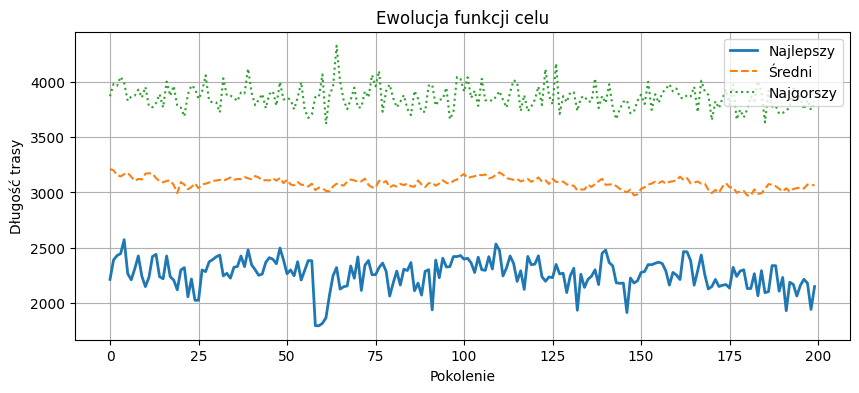

In [ ]:
plot_history(best_h, avg_h, worst_h)

Animacja zapisana jako evolution.gif


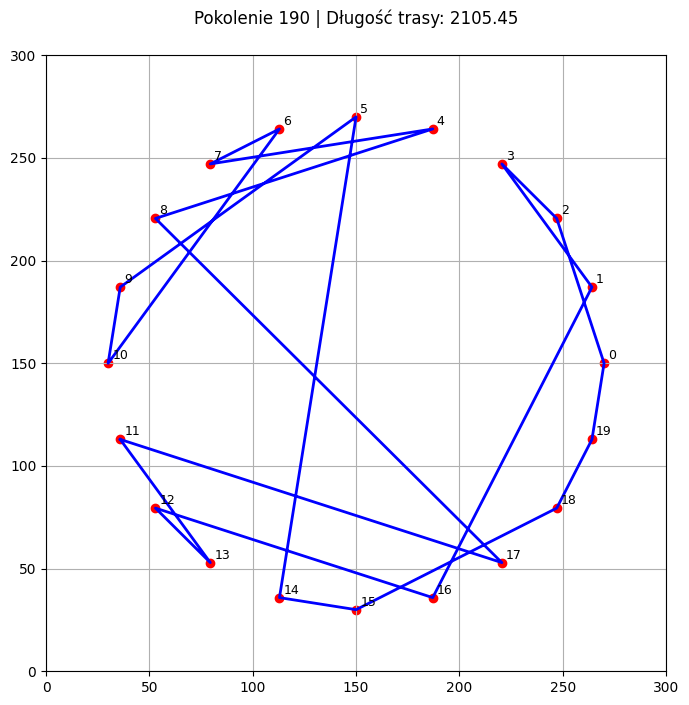

In [ ]:
animate_evolution(cities, paths_per_gen, save_as_gif=True)